# Introduction

In this study, we will simulate a two-dimensional heat diffusion model using various computational packages to compare their performance in terms of compilation speed. We will explore a total of four methods to solve the heat diffusion equation, each progressively faster than the last. We’ll start with basic matrix multiplication as a baseline. Next, we’ll significantly increase the speed, over 10 times faster, by applying sparse matrix operations. Building on this, we’ll achieve a speedup of more than 100 times compared to the baseline with NumPy arrays. Finally, we’ll maximize performance by using `JAX` for just-in-time compilation.

The following section introduces and loads all the necessary packages for this study.

In [1]:
import jax
import time
import timeit
import inspect
import numpy as np
import jax.numpy as jnp
from matplotlib import pyplot as plt

## Setting Up Initial Conditions

The two-dimensional heat equation is expressed as a partial differential equation that describes how heat diffuses over a surface area over time: 
$$
\frac{\partial u}{\partial t} = \epsilon \left( \frac{\partial^2 u}{\partial x^2} + \frac{\partial^2 u}{\partial y^2} \right)
$$
The function $u(x, y, t)$ represents the value of temperature at position $(x, y)$ at time $t$. <br>
There are two parameters to consider:
1. $\epsilon$, represents the diffusion coefficient that controls the rate at which heat spreads through the medium. 
2. $N$, the spatial resolution in each dimension of the simulation grid.

In this study, we will set N=101 and epsilon = 0.2 for our code:

In [2]:
# Initialize parameters
N = 101
epsilon = 0.2

We begin by creating an N×N temperature grid where every point has initial temperature equals to 0. Then we introduce a central heat source by setting the temperature at the grid's midpoint to 1. This point acts as the starting point from which heat will diffuse outward over time. This setup can be visualized in the following image, illustrating the initial heat concentration at the center.

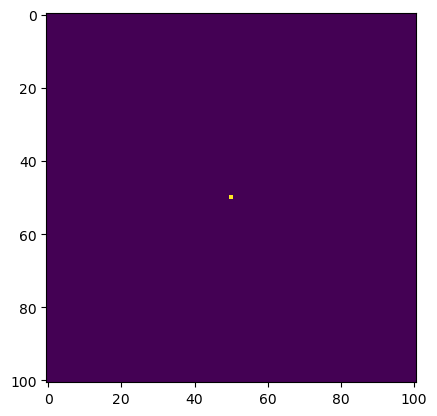

In [3]:
# Construct initial condition: 1 unit of heat at midpoint. 
u0 = np.zeros((N, N))
u0[int(N/2), int(N/2)] = 1.0
plt.imshow(u0)

All of the simulations we conduct will run for 2700 iterations, during which we will capture snapshots of the matrix by recording its state every 300 iterations. To facilitate this process, we will define two functions to assist with the simulation and documentation.

The first function is called `simulator` that simulates the heat diffusion. It takes two arguments: the initial state of the matrix u and the operation function used to update the matrix. Inside the function, we create a list called `val` to store the matrix states at every 300th iteration. Over 2700 iterations, a for loop continuously updates the matrix using the operation function. If the current iteration is divisible by 300, we append the matrix state to the `val`. After completing all iterations, the function returns the `val` containing the records.

In [4]:
def simulator(u, function):
    """
    Runs the simulation for a specified function
    Args:
        u, np.ndarray, the initial grid
        function, function, the simulation function by one time step.
    Returns:
        val, list, states of u at each 300 iteration interval
    """
    # Initialize number of iteration
    iter = 2700
    # Initialize an empty list to store states for each 300 iterations
    val = []
    for i in range(iter):
        u = function(u)
        # Document value for every 300 iterations
        if i % 300 == 0:
            val.append(u.copy())
    return val

The next function we build is responsible for visualizing the simulation process. We create a 3x3 grid to display each recorded matrix from the simulation. The function, takes the `val` list and generates a series of heatmaps for these matrices. 

In [5]:
def plot_simulation(val):
    """
    Plots the simulation snapshots for every 300 iterations
    Args:
        val, list, states of u at each 300 iteration interval
    """
    fig, axes = plt.subplots(3, 3)
    for i, ax in enumerate(axes.flatten()):
        ax.imshow(val[i])
        ax.set_title(f"{300 * (i + 1)}th Iteration ")
        ax.axis('off')
    plt.show()

## Matrix-vector Multiplication Simulation

We start the simulation process with the most basic approach: matrix-vector multiplication. We define a function called `advance_time_matvecmul` that operates matrix multiplication and advances the simulation by one time step at a time. This function takes three parameters: A, the 2D finite difference matrix; u, the N×N grid state at the current timestep k; and epsilon, the stability constant. We first obtain the grid size in the function by inspecting the shape. We then continue the operation by flattening the matrix u into a 1D vector and computing the temperature changes at each point on the grid.By repeatedly calling `advance_time_matvecmul` function, we simulate the diffusion of heat over time.

In [6]:
# Import advance_time_matvecmul(A, u, epsilon)
from heat_equation import advance_time_matvecmul
print(inspect.getsource(advance_time_matvecmul))

def advance_time_matvecmul(A, u, epsilon):
    """Advances the simulation by one timestep, via matrix-vector multiplication
    Args:
        A: The 2d finite difference matrix, N^2 x N^2. 
        u: N x N grid state at timestep k.
        epsilon: stability constant.

    Returns:
        N x N Grid state at timestep k+1.
    """
    N = u.shape[0]
    u = u + epsilon * (A @ u.flatten()).reshape((N, N))
    return u



Next, we move on to define the two-dimensional finite difference matrix A with size $N^2 \times N^2$. The matrix has −4 on the main diagonal, and 1 on the diagonals adjacent to the main diagonal. All other entries are zero. To visualize A, image a $N^2 \times N^2$ with the following format:
$$A = \begin{pmatrix}
  -4 & 1 & 0 & \cdots & 0 & 0 \\
  1 & -4 & 1 & \cdots & 0 & 0 \\
  0 & 1 & -4 & \cdots & 0 & 0 \\
  \vdots & \vdots & \vdots & \ddots & \vdots & \vdots \\
  0 & 0 & 0 & \cdots & -4 & 1 \\
  0 & 0 & 0 & \cdots & 1 & -4 \\
\end{pmatrix}$$

To construct the matrix as shown above, we start by defining the size of the flattened grid. Then, we fill the main diagonal with −4 and set the neighboring diagonals to 
1 representing adjacent entries. Boundary entries are set to zero using `diagonals[1][(N-1)::N] = 0` and `diagonals[2][(N-1)::N] = 0` Lastly, we assemble matrix A by combining all the diagonals we just |defined.

In [7]:
# Import get_A(N)
from heat_equation import get_A
print(inspect.getsource(get_A))

def get_A(N):
    """
    Build a heat diffusion matrix A for the 2D heat equation.
    Args:
        N, int, number of grid points of one dimension
    Returns:
        A, matrix, heat diffusion matrix of size N^2 x N^2.
    """
    n = N * N
    diagonals = [-4 * np.ones(n), np.ones(n-1), np.ones(n-1), np.ones(n-N), np.ones(n-N)]
    diagonals[1][(N-1)::N] = 0
    diagonals[2][(N-1)::N] = 0
    A = (np.diag(diagonals[0]) + np.diag(diagonals[1], 1) + np.diag(diagonals[2], -1) +
        np.diag(diagonals[3], N) + np.diag(diagonals[4], -N))
    
    return A



Now, we define matrix A using the code we implemented.

In [8]:
# Set the heat diffusion matrix
A = get_A(N)

Next, we begin the simulation of the matrix multiplication using the simulator function. To record the time it takes to complete 2700 iterations, we will use `%%timeit`. For clarity and to avoid modifying the original initial condition, we pass `u0.copy()` instead of `u0` into the simulator. Since we are passing a function with additional parameters, we use a `lambda` function to properly call the simulator.

In [22]:
%%timeit
# Simulation with matrix multiplication
val_1 = simulator(u0.copy(), lambda u: advance_time_matvecmul(A, u, epsilon))

36.7 s ± 388 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


We will also call the `plot_simulation` function to visualize the process of heat diffusion. 

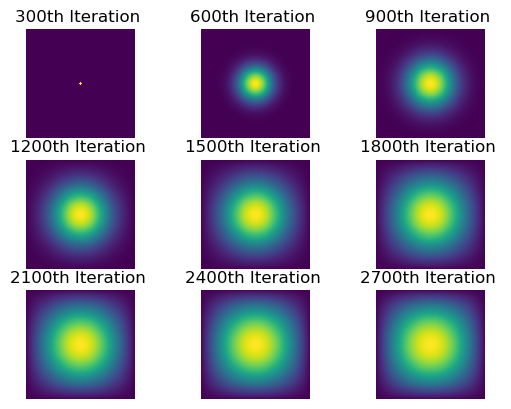

In [10]:
# Visualize the simulation of matrix multiplication
plot_simulation(val_1)

## Sparse Matrix in JAX Simulation

As evidenced by the compilation time, matrix multiplication is an inefficient process for simulating heat diffusion. This inefficiency arises because matrix A contains fewer than 5N² non-zero elements out of a total of N⁴ elements, leading to significant computational waste. Using a sparse matrix can address this issue by storing only the non-zero elements. In the following section, we will implement a sparse matrix for A to accelerate the computation process.

We can use the batched coordinate format to achieve this optimization. First, we will define matrix A using the previous function. Then, we will convert it to the batched coordinate format using `sparse.BCOO.fromdense(A)`.

In [26]:
# Import get_sparse_A(N)
from heat_equation import get_sparse_A
print(inspect.getsource(get_sparse_A))

def get_sparse_A(N):
    """
    Build a sparse format heat diffusion matrix A_sp_matrix
    Args:
        N, int, number of grid points of one dimension
    Returns:
        A_sp_matrix, matrix in sparse format, heat diffusion matrix of size N^2 x N^2.
    """
    A = get_A(N)
    A_sp_matrix = sparse.BCOO.fromdense(A)
    
    return A_sp_matrix



We obtain the sparse format matrix by using the function defined above.

In [27]:
# Set the heat diffusion matrix
A_sp_matrix = get_sparse_A(N)

Now, let's examine the simulation time and the corresponding visualization.

In [32]:
%%timeit
# Simulation with sparse matrix
val_2 = simulator(u0.copy(), lambda u: advance_time_matvecmul(A_sp_matrix, u, epsilon))

1.96 s ± 107 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


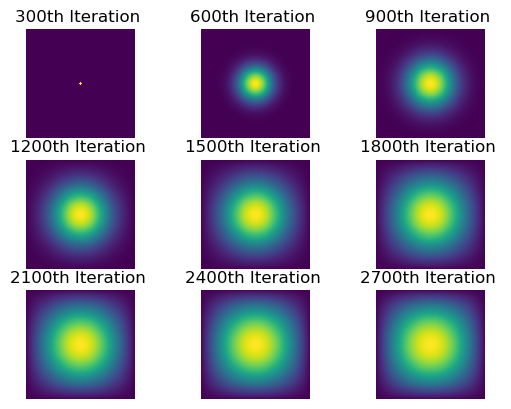

In [31]:
# Visualize the simulation of sparse matrix operation
plot_simulation(val_2)

## Simulation with `NumPy`

Matrix multiplication is useful but not necessary. We can employ vectorized array operations that enable more efficient element-wise computations without explicit loops. The `np.roll()` function in NumPy shifts the elements of an array along a specified axis, effectively "rolling" the data. You can check out the documentation and detailed explanation [here](https://numpy.org/doc/stable/reference/generated/numpy.roll.html). 

To build a function with NumPy array operation, let's start by padding the array with zeroes to create a larger array. This array has a $(N+2) \times (N+2)$ size that help us to handle the boundary conditions. Imagine the boundry elements do not have neighbors outside the grid that we need to worry about. Then, we compute the next time step by shifting the array in all four directions, up, down, left, and right, and we combine these shifted arrays to approximate the heat diffusion process. Lastly, we slice the array and convert the result back to the original grid size of $N \times N$.

In [15]:
# Import advance_time_numpy(u, epsilon)
from heat_equation import advance_time_numpy
print(inspect.getsource(advance_time_numpy))

def advance_time_numpy(u, epsilon):
    """
    Use vectorized array operations to advance the heat diffusion simulation speed
    Args:
        u: N x N grid state at timestep k.
        epsilon: stability constant.
    Returns:
        next: N x N Grid state at timestep k+1.
    """
    # Initialize a (N+2) x (N+2) array with 0
    array_0 = np.pad(u, pad_width = 1, mode='constant', constant_values=0)
    
    # Compute the next by roll along all directions
    next_time_step = array_0 + epsilon * (
        np.roll(array_0, 1, axis=0) + np.roll(array_0, -1, axis=0) +
        np.roll(array_0, 1, axis=1) + np.roll(array_0, -1, axis=1) - 4 * array_0)
        
    # Convert to N x N grid
    next = next_time_step[1:-1, 1:-1]
    return next



Once again, let's take a look at the simulation time and the resulting visualization

In [24]:
%%timeit
# Simulation with NumPy array operation
val_3 = simulator(u0.copy(), lambda u: advance_time_numpy(u, epsilon))

257 ms ± 103 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


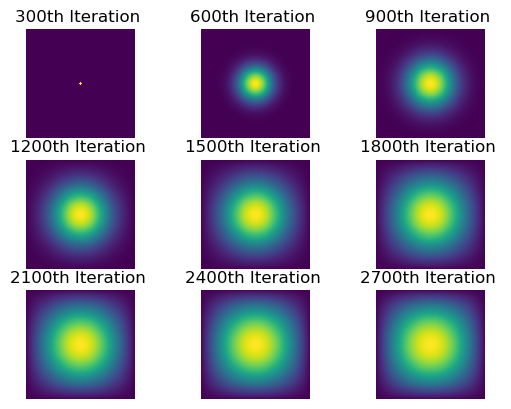

In [17]:
# Visualize the simulation of NumPy array operation
plot_simulation(val_3)

## Simulation with `jax.jit`

To achieve a final performance boost, we will use just-in-time compilation with JAX. JAX is designed to accelerate numerical computations by compiling Python functions. The setup is almost identical to what we did with the NumPy array operation, except we change `np` to `jnp` that stands for JAX numpy array in the code to use JAX. We need to inform JAX to apply just-in-time compilation for the function we defined. So we add a decorator, `@jax.jit`, before the function.

In [18]:
# Import advance_time_jax(u, epsilon)
from heat_equation import advance_time_jax
print(inspect.getsource(advance_time_jax))

@jax.jit
def advance_time_jax(u, epsilon):
    """
    Advance the heat diffusion simulation speed based on NumPy operations
    Args:
        u: N x N grid state at timestep k.
        epsilon: stability constant.
    Returns:
        next: N x N Grid state at timestep k+1.
    """
    # Initialize a (N+2) x (N+2) array with 0
    array_0 = jnp.pad(u, pad_width = 1, mode='constant', constant_values=0)
    
    # Compute the next by roll along all directions
    next_time_step = array_0 + epsilon * (
        jnp.roll(array_0, 1, axis=0) + jnp.roll(array_0, -1, axis=0) +
        jnp.roll(array_0, 1, axis=1) + jnp.roll(array_0, -1, axis=1) - 4 * array_0)
        
    # Convert to N x N grid
    next = next_time_step[1:-1, 1:-1]
    return next



The simulation speed and visualization will be as follows: 

In [25]:
%%timeit
# Simulation with jit
val_4 = simulator(u0.copy(), lambda u: advance_time_jax(u, epsilon))

56.4 ms ± 24.6 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


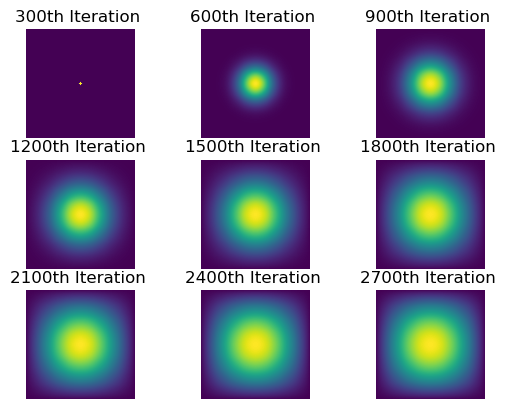

In [20]:
# Visualize the simulation of jit
plot_simulation(val_4)

# Discussion & Conclusion

Let’s compare the run times of four different simulations and discuss the results. Matrix multiplication takes an average of 36.7 seconds to complete 2700 iterations. For the same number of iterations, sparse matrix multiplication takes only 1.96 seconds, which is approximately 18.72 times faster than the plain matrix multiplication. When using NumPy arrays, the simulation takes just 0.257 seconds, making it 7.63 times faster than sparse matrix multiplication and 142.80 times faster than matrix multiplication. Finally, with just-in-time compilation using JAX NumPy arrays, the simulation completes in only 0.0564 seconds, which is about 4.56 times faster than the NumPy array operation, 34.75 times faster than sparse matrix multiplication, and 650.71 times faster than matrix multiplication. Without a doubt, just-in-time compilation is the fastest, showing a significant speed advantage compared to the other operations.

Consider the implementation of the four simulator functions, you will see that the JAX is magical. The just-in-time compilation simulation is the simplest given the structure of NumPy array operations and sparse matrix operations in JAX are highly efficient with a single line of code to directly transform a matrix into sparse format. Overall, JAX proves to be extremely useful in enhancing computational efficiency for large-scale numerical computations.